# Recipe 1 — Track Discovery via Metadata Filters

This notebook walks through finding and selecting FILER tracks using standardized metadata
filters.

**What you'll learn:**
- How to query the FILER metadata endpoint
- How to filter by assay, cell type, tissue, life stage, and data source
- How to explore and summarize the results
- How to save a reusable Track Set manifest for downstream workflows

**Next steps after this notebook:**
- `02_query_and_summarize.ipynb` — query overlaps for your regions against the tracks found here

Run the following:
```
pip install -e ".[dev]"
```

## 0. Setup

In [14]:
import sys
import json
import requests
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone

from filerpy.client import search_tracks, ENDPOINTS
from filerpy.trackset import make_trackset, save_trackset, inspect_trackset

print(f"FILER endpoint: {ENDPOINTS['metadata']}")

FILER endpoint: https://tf.lisanwanglab.org/FILER2/get_metadata.php


---
## 1. Hello World — fetch a single known track

The fastest way to verify your connection to FILER is to look up one track by its identifier.

In [15]:
r = requests.get(
    "https://tf.lisanwanglab.org/FILER2/get_metadata.php",
    params={"genomeBuild": "hg38", "trackID": "NGBLPL2W2SM2WC"},
    timeout=30,
)
r.raise_for_status()

track = r.json()[0]
print(json.dumps(track, indent=2))

{
  "identifier": "NGBLPL2W2SM2WC",
  "data_source": "Blueprint",
  "file_name": "57418.Blueprint.ERS792033.WGB-Seq.peak_calls.bed.gz",
  "number_of_intervals": 738551,
  "bp_covered": 1857857024,
  "output_type": "peaks",
  "genome_build": "hg38",
  "cell_type": "B cell",
  "biosample_type": "Primary cell",
  "biosamples_term_id": "CL_2000006",
  "tissue_category": "Blood",
  "encode_experiment_id": "Not applicable",
  "biological_replicate": "Not applicable",
  "technical_replicate": "Not applicable",
  "antibody": "Not applicable",
  "assay": "WGB-Seq",
  "file_format": "bed bed4",
  "file_size": 8541765,
  "downloaded_date": "03/12/2021",
  "release_date": "08/31/2016",
  "date_added_to_filer": "04/10/2021",
  "processed_file_download_url": "https://tf.lisanwanglab.org/GADB/FILER2/Annotationtracks/IHEC/IHEC_Blueprint/WGB-Seq/bed4/hg38/57418.Blueprint.ERS792033.WGB-Seq.peak_calls.bed.gz",
  "processed_file_md5": "30bf3adf841fd5c17a1832fef34f6c76",
  "link_out_url": "https://ihec-epi

---
## 2. Search by metadata filters

Use `search_tracks()` to query the endpoint with one or more filters.

| Friendly name    | PHP param         | Example              |
|------------------|-------------------|----------------------|
| `assay`          | `assayType`       | `ATAC-seq`           |
| `cell_type`      | `cellType`        | `CD14+ monocyte`     |
| `tissue_category`| `tissueCategory`  | `Blood`              |
| `data_source`    | `dataSource`      | `ENCODE`             |
| `track_id`       | `trackID`         | `NGBLPL2W2SM2WC`     |

In [16]:
# ── Edit these filters to match your use case ──────────────────────────────
GENOME_BUILD = "hg38"
ASSAY        = "ATAC-seq"
TISSUE_CATEGORY = "Blood"
DATA_SOURCE  = None   # set to e.g. "ENCODE" to restrict, or leave None for all
# ───────────────────────────────────────────────────────────────────────────

filters = {}
if ASSAY:       filters["assayType"]  = ASSAY
if TISSUE_CATEGORY: filters["tissueCategory"] = TISSUE_CATEGORY
if DATA_SOURCE: filters["dataSource"] = DATA_SOURCE

print(f"Querying FILER ({GENOME_BUILD}) with filters: {filters}")

df = search_tracks(GENOME_BUILD, **filters)

print(f"\nFound {len(df)} tracks")
print(df.head().to_string())

Querying FILER (hg38) with filters: {'assayType': 'ATAC-seq', 'tissueCategory': 'Blood'}

Found 1116 tracks
       identifier genome_build     assay                                     cell_type                 biosample_type tissue_category system_category life_stage data_source         data_category                   classification             output_type                                                                                                                                               track_name                                                                                processed_file_download_url                                                                                                 tabix_file_url           file_name  number_of_intervals  bp_covered biosamples_term_id encode_experiment_id biological_replicate technical_replicate        antibody     file_format  file_size downloaded_date release_date date_added_to_filer                processed_file_md5          

### 2a. View key columns only

In [17]:
KEY_COLS = [
    "identifier", "assay", "cell_type", "biosample_type",
    "tissue_category", "life_stage", "data_source",
    "output_type", "track_name",
]

print(df[KEY_COLS].head(10).to_string())

       identifier     assay                                     cell_type                 biosample_type tissue_category life_stage data_source             output_type                                                                                                                                               track_name
0  NGENCD5BW3DYHL  ATAC-seq  Naive thymus-derived CD8+, alpha-beta T cell                   Primary cell           Blood      Adult      ENCODE   IDR thresholded peaks  ENCODE Naive thymus-derived CD8+, alpha-beta T cell (repl. 2) ATAC-seq IDR thresholded peaks (narrowPeak) [Experiment: ENCSR614JAG] [Life stage: Adult]
1  NGENC4P2SI32WC  ATAC-seq                                          K562                      Cell line           Blood      Adult      ENCODE  pseudoreplicated peaks                                      ENCODE K562 (repl. 1, 2) ATAC-seq pseudoreplicated peaks (narrowPeak) [Experiment: ENCSR483RKN] [Life stage: Adult]
2  NGENCBSUTVYWJF  ATAC-seq          

### 2b. Advanced: raw jq `filterString`

For power users — pass a raw jq expression directly for full Boolean flexibility.

In [18]:
df_advanced = search_tracks(
    "hg38",
    filter_string='.assay == "ATAC-seq" and .tissue_category == "Blood"',
)
print(f"filterString query returned {len(df_advanced)} tracks")
print(df_advanced[KEY_COLS].head(5).to_string())

filterString query returned 1116 tracks
       identifier     assay                                     cell_type                 biosample_type tissue_category life_stage data_source             output_type                                                                                                                                               track_name
0  NGENCD5BW3DYHL  ATAC-seq  Naive thymus-derived CD8+, alpha-beta T cell                   Primary cell           Blood      Adult      ENCODE   IDR thresholded peaks  ENCODE Naive thymus-derived CD8+, alpha-beta T cell (repl. 2) ATAC-seq IDR thresholded peaks (narrowPeak) [Experiment: ENCSR614JAG] [Life stage: Adult]
1  NGENC4P2SI32WC  ATAC-seq                                          K562                      Cell line           Blood      Adult      ENCODE  pseudoreplicated peaks                                      ENCODE K562 (repl. 1, 2) ATAC-seq pseudoreplicated peaks (narrowPeak) [Experiment: ENCSR483RKN] [Life stage: Adul

---
## 3. Explore the results

Before committing to a track set, understand the shape of your results.

In [19]:
print("=== Tracks by data_source ===")
print(df["data_source"].value_counts().to_string())

=== Tracks by data_source ===
data_source
ENCODE    1116


In [20]:
print("=== Tracks by life_stage ===")
print(df["life_stage"].value_counts().to_string())

=== Tracks by life_stage ===
life_stage
Adult      1038
Unknown      48
Child        30


In [21]:
print("=== Tracks by output_type ===")
print(df["output_type"].value_counts().to_string())

=== Tracks by output_type ===
output_type
IDR thresholded peaks                 457
pseudoreplicated peaks                451
replicated peaks                      107
conservative IDR thresholded peaks    101


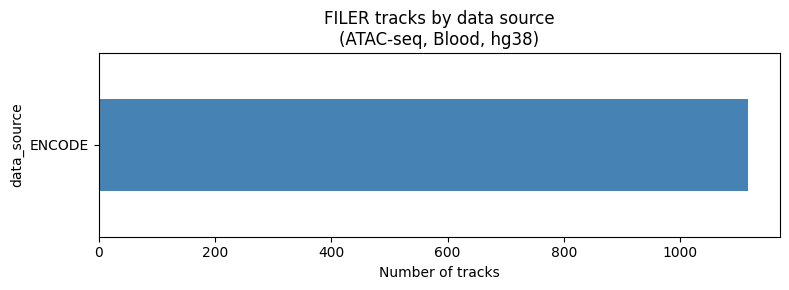

Saved tracks_by_source.png


In [ ]:
# Summary bar chart — tracks per data source
import matplotlib.pyplot as plt

counts = df["data_source"].value_counts()
fig, ax = plt.subplots(figsize=(8, max(3, len(counts) * 0.4)))
counts.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Number of tracks")
ax.set_title(f"FILER tracks by data source\n({ASSAY}, {TISSUE_CATEGORY}, {GENOME_BUILD})")
plt.tight_layout()
plt.show()

---
## 4. Refine your selection

You often want a subset of the returned tracks — e.g. only adult samples

In [23]:
# ── Edit this filter to match what you need ────────────────────────────────
df_filtered = df[
    (df["life_stage"] == "Adult")
].copy()
# ───────────────────────────────────────────────────────────────────────────

print(f"After refinement: {len(df_filtered)} tracks (from {len(df)} total)")
print(df_filtered[KEY_COLS].head().to_string())

After refinement: 1038 tracks (from 1116 total)
       identifier     assay                                     cell_type                 biosample_type tissue_category life_stage data_source             output_type                                                                                                                                               track_name
0  NGENCD5BW3DYHL  ATAC-seq  Naive thymus-derived CD8+, alpha-beta T cell                   Primary cell           Blood      Adult      ENCODE   IDR thresholded peaks  ENCODE Naive thymus-derived CD8+, alpha-beta T cell (repl. 2) ATAC-seq IDR thresholded peaks (narrowPeak) [Experiment: ENCSR614JAG] [Life stage: Adult]
1  NGENC4P2SI32WC  ATAC-seq                                          K562                      Cell line           Blood      Adult      ENCODE  pseudoreplicated peaks                                      ENCODE K562 (repl. 1, 2) ATAC-seq pseudoreplicated peaks (narrowPeak) [Experiment: ENCSR483RKN] [Life sta

In [24]:
# Sanity check: are all identifiers unique?
n_dupes = df_filtered["identifier"].duplicated().sum()
print(f"Duplicate identifiers: {n_dupes}")
if n_dupes > 0:
    print("Deduplicating...")
    df_filtered = df_filtered.drop_duplicates("identifier")

Duplicate identifiers: 0


---
## 5. Save results

### 5a. Save as TSV (simple)

In [ ]:
repo_root = Path().resolve().parents[1]
out_dir = repo_root / "examples" / "expected"
out_dir.mkdir(parents=True, exist_ok=True)

tsv_path = out_dir / "recipe01_tracks.tsv"
df_filtered.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved {len(df_filtered)} tracks → {tsv_path}")

NameError: name 'repo_root' is not defined

### 5b. Save as a Track Set manifest (recommended for reproducibility)

A Track Set pins your selection with the filters, genome build, and timestamp used to
produce it. This is the canonical input for all downstream recipes (query, summarize, deploy).

In [ ]:
trackset_name = (
    f"{ASSAY.replace('-', '').lower()}"
    f"_{CELL_TYPE.replace(' ', '_').replace('+', 'pos')}"
    f"_{GENOME_BUILD}"
)

trackset = make_trackset(
    df           = df_filtered,
    genome_build = GENOME_BUILD,
    filters      = filters,
    name         = trackset_name,
)

ts_dir = repo_root / "examples" / "tracksets"
json_path, tsv_path = save_trackset(
    trackset,
    out_dir   = ts_dir,
    write_tsv = True,
    df        = df_filtered,
)

print(f"Track Set JSON : {json_path}")
print(f"Track Set TSV  : {tsv_path}")

Track Set JSON : /Users/divak2004/Documents/GitHub/FILER-workflows/examples/tracksets/atacseq_B_cell_hg38.trackset.json
Track Set TSV  : /Users/divak2004/Documents/GitHub/FILER-workflows/examples/tracksets/atacseq_B_cell_hg38.trackset.tsv


In [ ]:
# Inspect the manifest
inspect_trackset(trackset)

               name genome_build           created_at  track_count filer_release                                              filters
atacseq_B_cell_hg38         hg38 2026-02-25T21:24:58Z            0          None {"assayType": "ATAC-seq", "tissueCategory": "Blood"}


,name,genome_build,created_at,track_count,filer_release,filters
0,atacseq_B_cell_hg38,hg38,2026-02-25T21:24:58Z,0,None,"{""assayType"": ""ATAC-seq"", ""tissueCategory"": ""B..."


In [ ]:
# Preview the full JSON
print(json.dumps(trackset, indent=2))

{
  "name": "atacseq_B_cell_hg38",
  "genome_build": "hg38",
  "created_at": "2026-02-25T21:24:58Z",
  "filters": {
    "assayType": "ATAC-seq",
    "tissueCategory": "Blood"
  },
  "track_count": 0,
  "track_ids": [],
  "filer_release": null
}


---
## 6. Batch queries across multiple filter combinations

If you need tracks for multiple assays or cell types, loop and concatenate.

In [ ]:
filter_sets = [
    {"assayType": "ATAC-seq",  "tissueCategory": "Blood"},
    {"assayType": "DNase-seq", "tissueCategory": "Blood"},
    {"assayType": "ChIP-seq",  "tissueCategory": "Blood"},
]

frames = []
for f in filter_sets:
    result = search_tracks(GENOME_BUILD, **f)
    print(f"  {f} → {len(result)} tracks")
    frames.append(result)

df_multi = pd.concat(frames, ignore_index=True).drop_duplicates("identifier")
print(f"\nTotal unique tracks across all filter sets: {len(df_multi)}")
print(df_multi["assay"].value_counts().to_string())

  {'assayType': 'ATAC-seq', 'tissueCategory': 'Blood'} → 1116 tracks
  {'assayType': 'DNase-seq', 'tissueCategory': 'Blood'} → 1366 tracks
  {'assayType': 'ChIP-seq', 'tissueCategory': 'Blood'} → 1662 tracks

Total unique tracks across all filter sets: 4144
assay
ChIP-seq     1662
DNase-seq    1366
ATAC-seq     1116


---
## 7. Next steps

You now have a `tracks.tsv` and a `.trackset.json` ready for downstream use.

| What to do next                                        | Recipe / Notebook            |
|--------------------------------------------------------|------------------------------|
| Query overlaps for a genomic region against these tracks | Recipe 3.1 / `02_query_and_summarize.ipynb` |
| Batch-query a BED file of regions                      | Recipe 3.2                   |
| Summarize overlaps by assay / cell type                | Recipe 4.1                   |
| Deploy tracks locally for fast offline queries         | Recipe 2.2                   |

```python
# Quick reference: load your saved track set in a future session
from filerpy.trackset import load_trackset
ts = load_trackset("examples/tracksets/<your_name>.trackset.json")
print(ts["track_ids"][:5])
```